In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.preprocessing.clean_data import DataPreprocessor
from src.features.behavioral_features import BehavioralFeatureEngineer
from src.features.device_features import DeviceFeatureEngineer

sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 120

CONFIG = '../config/config.yaml'

## Step 1: Load Processed Data

In [2]:
# Option A: Load pre-processed parquet (fast)
import os
processed_path = '../data/processed/processed_train.parquet'

if os.path.exists(processed_path):
    df = pd.read_parquet(processed_path)
    print(f'Loaded processed data: {df.shape}')
else:
    # Option B: Run preprocessing (slower, ~5-10 mins)
    print('Running preprocessing...')
    prep = DataPreprocessor(CONFIG)
    df = prep.run(save=True)
    print(f'Preprocessed: {df.shape}')

Loaded processed data: (590540, 443)


## Step 2: Behavioral Features

In [3]:
beh = BehavioralFeatureEngineer()
df_beh = beh.fit_transform(df.copy())

new_cols = [c for c in df_beh.columns if c not in df.columns]
print(f'New behavioral features: {len(new_cols)}')
print(new_cols)

2026-03-05 02:53:19.250 | INFO     | src.features.behavioral_features:fit_transform:53 - Computing card-level behavioral aggregates …


New behavioral features: 20
['card_tx_count', 'card_tx_mean_amt', 'card_tx_std_amt', 'card_tx_max_amt', 'card_tx_min_amt', 'card_hour_mean', 'card_freq_product_0', 'card_freq_product_1', 'card_freq_product_2', 'card_freq_product_3', 'card_freq_product_4', 'card_merchant_entropy', 'amount_zscore', 'card_amount_ratio', 'time_since_last_tx', 'card_tx_count_1h', 'card_tx_count_24h', 'card_tx_count_7d', 'tx_is_night', 'tx_is_weekend']


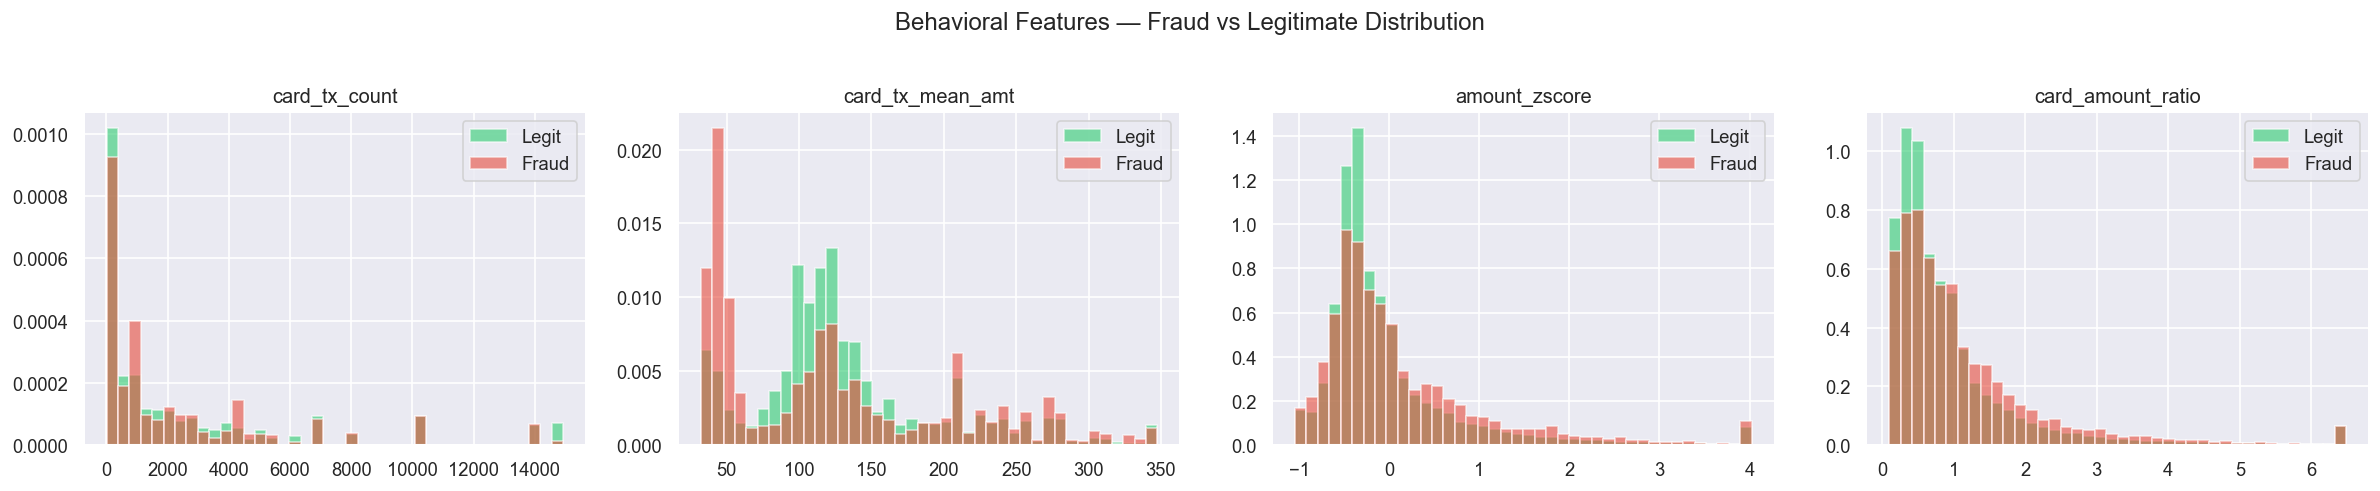

In [4]:
# Analyse key behavioral features vs fraud
beh_features = ['card_tx_count', 'card_tx_mean_amt', 'amount_zscore', 'card_amount_ratio']
existing_beh = [c for c in beh_features if c in df_beh.columns]

if existing_beh:
    fig, axes = plt.subplots(1, len(existing_beh), figsize=(5*len(existing_beh), 4))
    if len(existing_beh) == 1:
        axes = [axes]

    for ax, feat in zip(axes, existing_beh):
        fraud = df_beh[df_beh['isFraud']==1][feat].clip(
            *df_beh[feat].quantile([0.01, 0.99]).values)
        legit = df_beh[df_beh['isFraud']==0][feat].clip(
            *df_beh[feat].quantile([0.01, 0.99]).values)
        ax.hist(legit, bins=40, alpha=0.6, color='#2ecc71', label='Legit', density=True)
        ax.hist(fraud, bins=40, alpha=0.6, color='#e74c3c', label='Fraud', density=True)
        ax.set_title(feat)
        ax.legend()

    plt.suptitle('Behavioral Features — Fraud vs Legitimate Distribution', y=1.02)
    plt.tight_layout()
    plt.show()

## Step 3: Device Features

In [5]:
dev = DeviceFeatureEngineer()
df_dev = dev.fit_transform(df_beh.copy())

new_dev_cols = [c for c in df_dev.columns if c not in df_beh.columns]
print(f'New device features: {len(new_dev_cols)}')
print(new_dev_cols)

2026-03-05 02:57:00.531 | INFO     | src.features.device_features:fit_transform:62 - Computing device-level fraud features …


New device features: 13
['device_user_count', 'device_tx_count', 'device_fraud_rate', 'device_risk_score', 'email_user_count', 'email_domain_fraud_rate', 'addr_user_count', 'addr_fraud_rate', 'card_device_count', 'card_email_count', 'device_type_risk', 'identity_mismatch_score', 'device_is_high_risk']


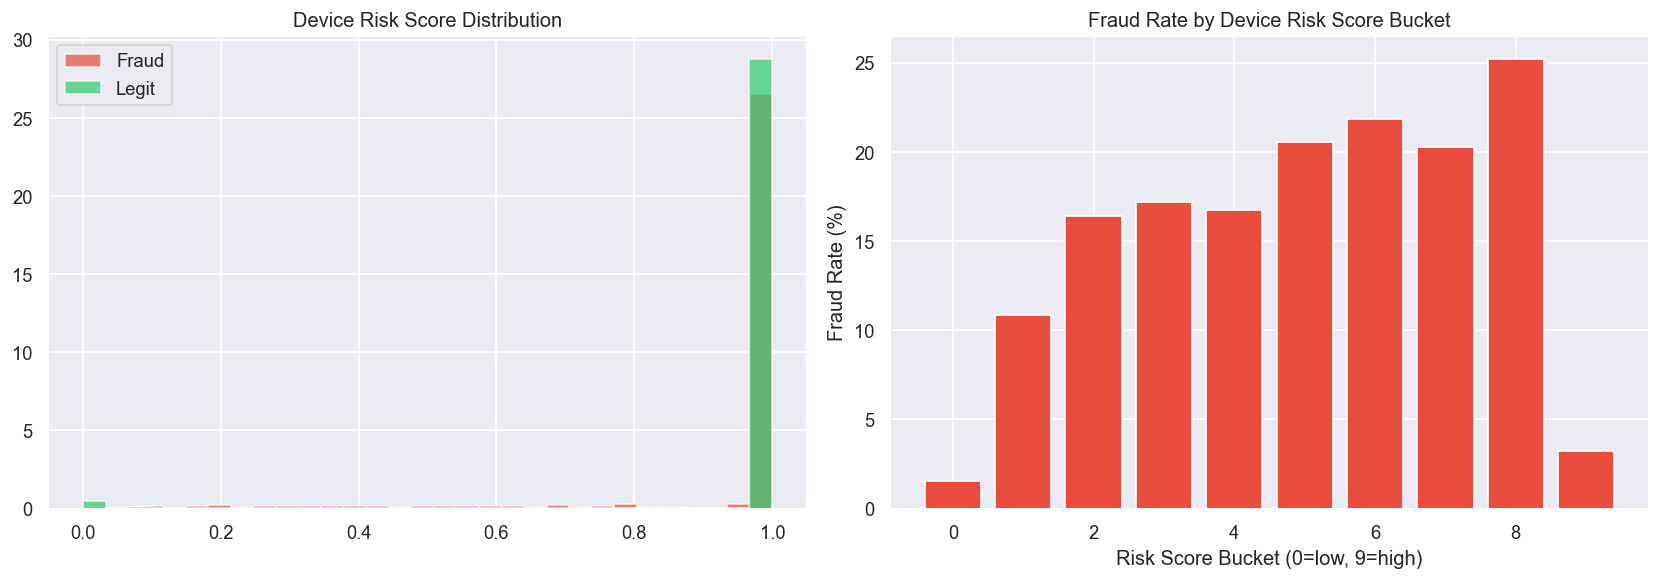

In [6]:
# Device risk score analysis
if 'device_risk_score' in df_dev.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Distribution
    df_dev[df_dev['isFraud']==1]['device_risk_score'].hist(
        bins=30, ax=axes[0], color='#e74c3c', alpha=0.7, label='Fraud', density=True)
    df_dev[df_dev['isFraud']==0]['device_risk_score'].hist(
        bins=30, ax=axes[0], color='#2ecc71', alpha=0.7, label='Legit', density=True)
    axes[0].set_title('Device Risk Score Distribution')
    axes[0].legend()

    # Fraud rate by device risk bucket
    df_dev['risk_bucket'] = pd.cut(df_dev['device_risk_score'],
                                    bins=10, labels=False)
    bucket_fraud = df_dev.groupby('risk_bucket')['isFraud'].mean()
    axes[1].bar(range(len(bucket_fraud)), bucket_fraud.values * 100, color='#e74c3c')
    axes[1].set_title('Fraud Rate by Device Risk Score Bucket')
    axes[1].set_xlabel('Risk Score Bucket (0=low, 9=high)')
    axes[1].set_ylabel('Fraud Rate (%)')

    plt.tight_layout()
    plt.show()

## Step 4: Feature Correlation with Fraud

Total numeric features: 473


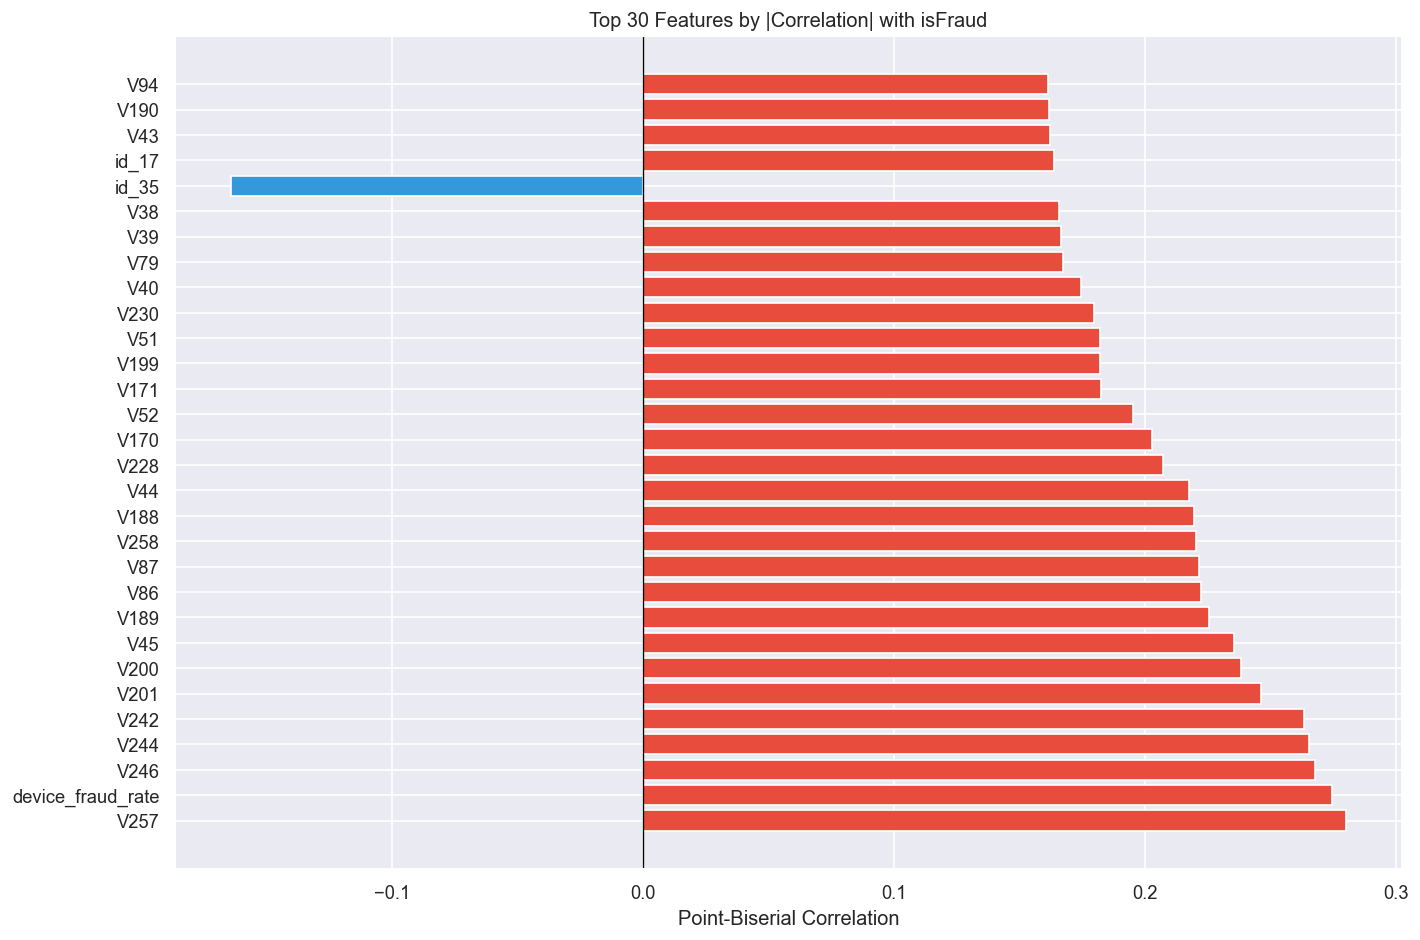


Top 15 most correlated features:
          feature  correlation
             V257     0.280214
device_fraud_rate     0.274551
             V246     0.268090
             V244     0.265712
             V242     0.263476
             V201     0.246462
             V200     0.238290
              V45     0.235436
             V189     0.225829
              V86     0.222343
              V87     0.221568
             V258     0.220304
             V188     0.219590
              V44     0.217870
             V228     0.207138


In [7]:
# Point-biserial correlation of all numeric features with isFraud
numeric_cols = df_dev.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['TransactionID', 'isFraud']]

correlations = []
for col in numeric_cols:
    try:
        corr = df_dev[col].corr(df_dev['isFraud'])
        if not np.isnan(corr):
            correlations.append({'feature': col, 'correlation': corr})
    except:
        pass

corr_df = pd.DataFrame(correlations).sort_values('correlation', key=abs, ascending=False)
print(f'Total numeric features: {len(corr_df)}')

top_n = 30
top_corr = corr_df.head(top_n)

plt.figure(figsize=(12, 8))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in top_corr['correlation']]
bars = plt.barh(top_corr['feature'], top_corr['correlation'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'Top {top_n} Features by |Correlation| with isFraud')
plt.xlabel('Point-Biserial Correlation')
plt.tight_layout()
plt.show()

print("\nTop 15 most correlated features:")
print(top_corr.head(15).to_string(index=False))

## Step 5: Quick LightGBM Sanity Check

In [9]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

NON_FEAT = {'isFraud', 'TransactionID', 'TransactionDT', 'tx_day', 'tx_week'}
feature_cols = [c for c in df_dev.columns if c not in NON_FEAT
                and df_dev[c].dtype != object]

X = df_dev[feature_cols].fillna(0)
y = df_dev['isFraud']

# Time-based split
n_val = int(len(X) * 0.2)
X_train, X_val = X.iloc[:-n_val], X.iloc[-n_val:]
y_train, y_val = y.iloc[:-n_val], y.iloc[-n_val:]

print(f'Train: {len(X_train):,} | Val: {len(X_val):,}')
print(f'Fraud rate (train): {y_train.mean():.4%}')

neg, pos = (y_train==0).sum(), (y_train==1).sum()
model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    scale_pos_weight=neg/pos,
    n_jobs=-1,
    random_state=42,
    verbose=-1
)

model.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(20, verbose=False)])

proba = model.predict_proba(X_val)[:, 1]
roc = roc_auc_score(y_val, proba)
pr = average_precision_score(y_val, proba)

print(f'\nQuick Model Results:')
print(f'  ROC-AUC : {roc:.4f}')
print(f'  PR-AUC  : {pr:.4f}')

Train: 472,432 | Val: 118,108
Fraud rate (train): 3.5135%

Quick Model Results:
  ROC-AUC : 0.8258
  PR-AUC  : 0.2548


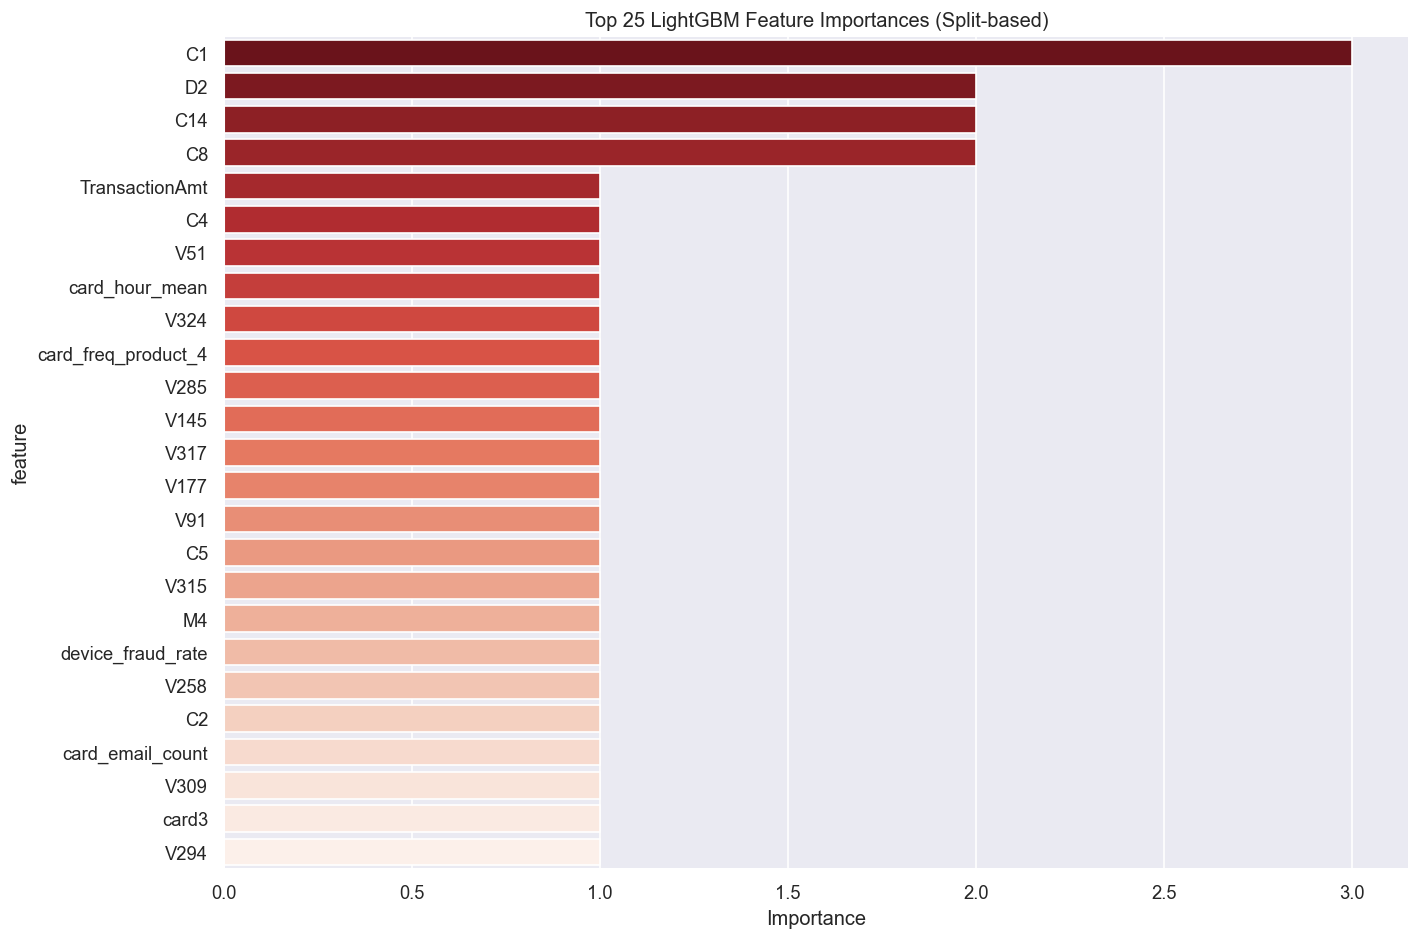

In [10]:
# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(25)

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x='importance', y='feature', palette='Reds_r')
plt.title('Top 25 LightGBM Feature Importances (Split-based)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Step 6: SHAP Feature Importance

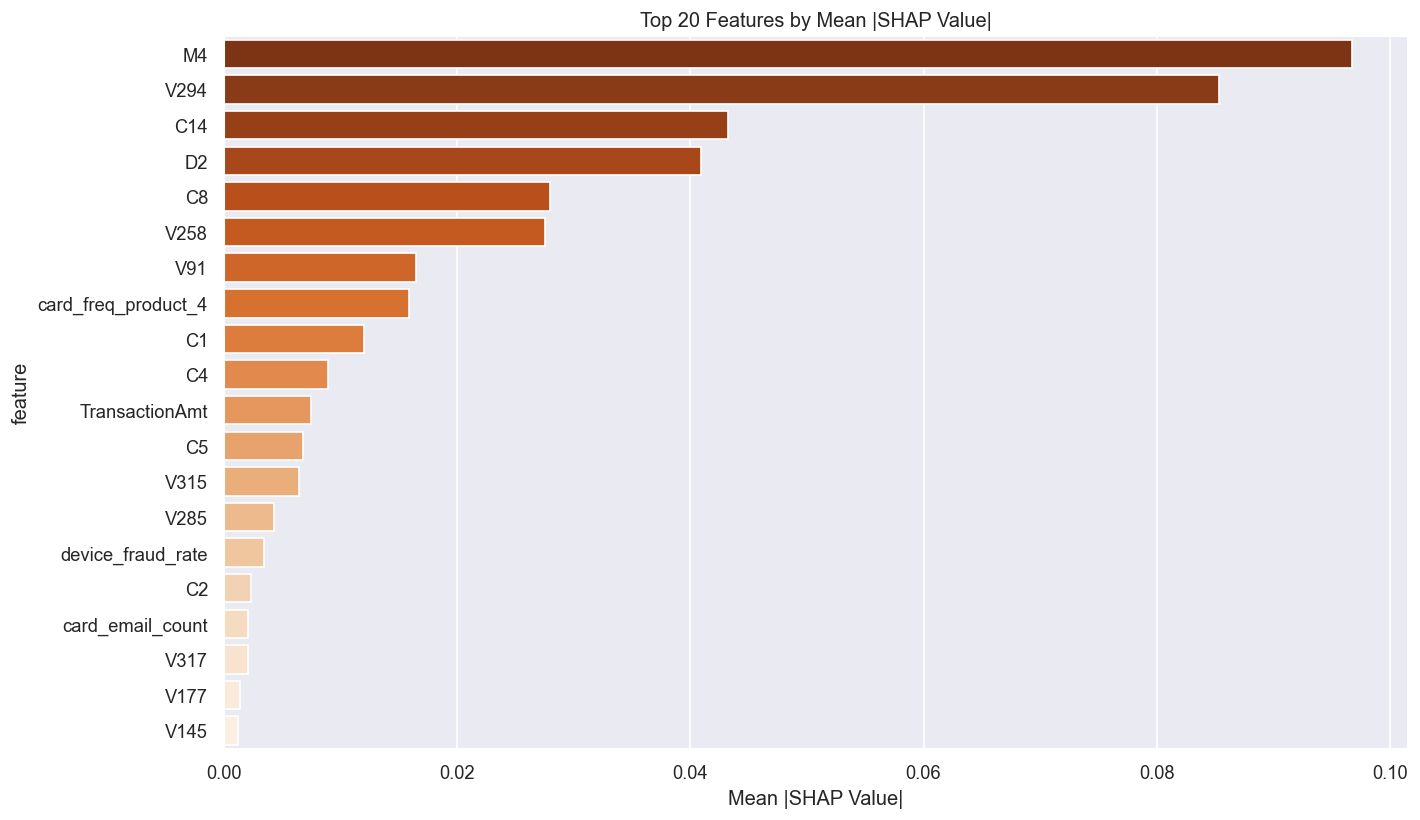

Top 10 SHAP features:
            feature  mean_abs_shap
                 M4       0.096741
               V294       0.085352
                C14       0.043226
                 D2       0.040913
                 C8       0.027973
               V258       0.027542
                V91       0.016512
card_freq_product_4       0.015918
                 C1       0.011988
                 C4       0.008911


In [11]:
import shap

sample_val = X_val.sample(min(2000, len(X_val)), random_state=42)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample_val)

if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

mean_abs_shap = np.abs(sv).mean(axis=0)
shap_df = pd.DataFrame({'feature': feature_cols, 'mean_abs_shap': mean_abs_shap})
shap_df = shap_df.sort_values('mean_abs_shap', ascending=False).head(20)

plt.figure(figsize=(12, 7))
sns.barplot(data=shap_df, x='mean_abs_shap', y='feature', palette='Oranges_r')
plt.title('Top 20 Features by Mean |SHAP Value|')
plt.xlabel('Mean |SHAP Value|')
plt.tight_layout()
plt.show()

print('Top 10 SHAP features:')
print(shap_df.head(10).to_string(index=False))

## Summary

In [12]:
print("="*60)
print("FEATURE ENGINEERING SUMMARY")
print("="*60)
print(f"\nOriginal features   : {len(df.columns)}")
print(f"After behavioral FE : {len(df_beh.columns)}")
print(f"After device FE     : {len(df_dev.columns)}")
print(f"ML-ready features   : {len(feature_cols)}")
print(f"\nQuick model performance (200 trees):")
print(f"  ROC-AUC : {roc:.4f}")
print(f"  PR-AUC  : {pr:.4f}")
print(f"\nTop 5 predictive features:")
for _, row in shap_df.head(5).iterrows():
    print(f"  {row['feature']:35s} SHAP={row['mean_abs_shap']:.4f}")
print("="*60)

FEATURE ENGINEERING SUMMARY

Original features   : 443
After behavioral FE : 463
After device FE     : 477
ML-ready features   : 472

Quick model performance (200 trees):
  ROC-AUC : 0.8258
  PR-AUC  : 0.2548

Top 5 predictive features:
  M4                                  SHAP=0.0967
  V294                                SHAP=0.0854
  C14                                 SHAP=0.0432
  D2                                  SHAP=0.0409
  C8                                  SHAP=0.0280
